# Data Ingestion & Quality Profiling




## 1. Load & Inspect


In [21]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
import pandas as pd
from google.colab import files

# Upload file
uploaded = files.upload()
df = pd.read_excel("car_prices final.xlsx")

df.head()

Saving car_prices final.xlsx to car_prices final (1).xlsx


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


##  Understanding the Data Structure


In [23]:
# Display data types of all columns
print("Data Types:")
print(df.dtypes)

# Display total number of records (rows)
print("\nTotal Record Count:", len(df))


Data Types:
year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object

Total Record Count: 558837


In [24]:
# Display number of rows and columns
print("Dataset Shape:", df.shape)

# Display rows and columns separately
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (558837, 16)
Number of Rows: 558837
Number of Columns: 16


In [25]:

# 1. Check shape of dataset
print("Dataset Shape:", df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# 2. Display column names
print("\nColumn Names:")
for col in df.columns:
    print(col)

# 3. Display data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (558837, 16)

Number of Rows: 558837
Number of Columns: 16

Column Names:
year
make
model
trim
body
transmission
vin
state
condition
odometer
color
interior
seller
mmr
sellingprice
saledate

Data Types:
year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object


## Missing & Anomaly Detection

In [26]:
# Calculate percentage of missing values also findinf count of missing values
# Count missing values
missing_values = df.isnull().sum()

# Calculate missing percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create summary dataframe
missing_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

# Sort by missing percentage
missing_df = missing_df.sort_values(
    by='Missing Percentage (%)',
    ascending=False
)

# Display result
missing_df

missing_df

,Data Type,Missing Count,Missing Percentage (%)
transmission,object,65352,11.694287
body,object,13195,2.361154
condition,float64,11820,2.115107
trim,object,10651,1.905922
model,object,10399,1.860829
make,object,10301,1.843292
color,object,749,0.134028
interior,object,749,0.134028
odometer,float64,94,0.016821
mmr,float64,38,0.006800


### Visualize Missing Values

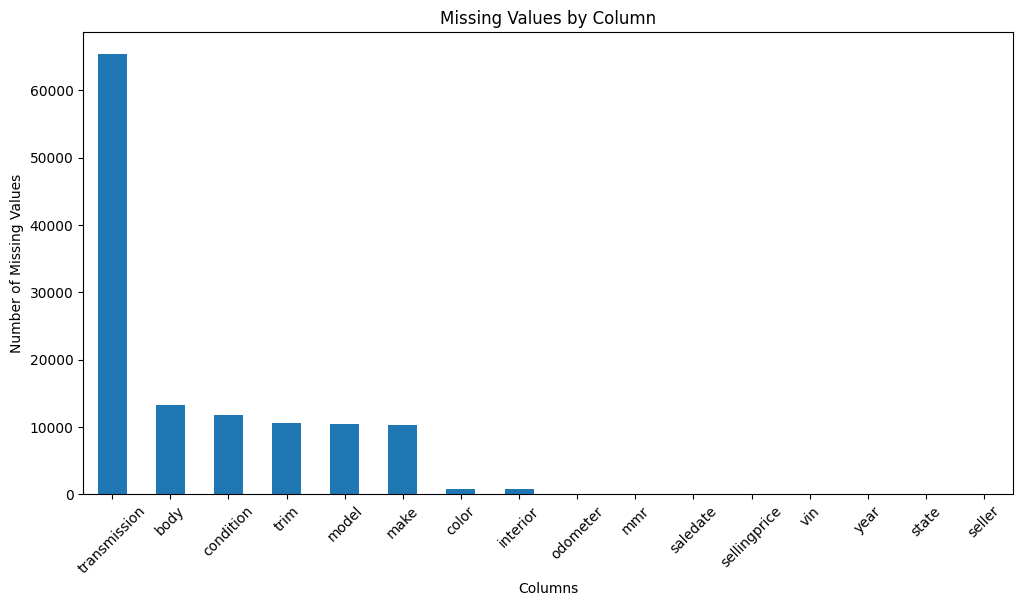

In [27]:
plt.figure(figsize=(12,6))

missing_values.sort_values(ascending=False).plot(
    kind='bar'
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.show()

### Heatmap (Professional EDA)

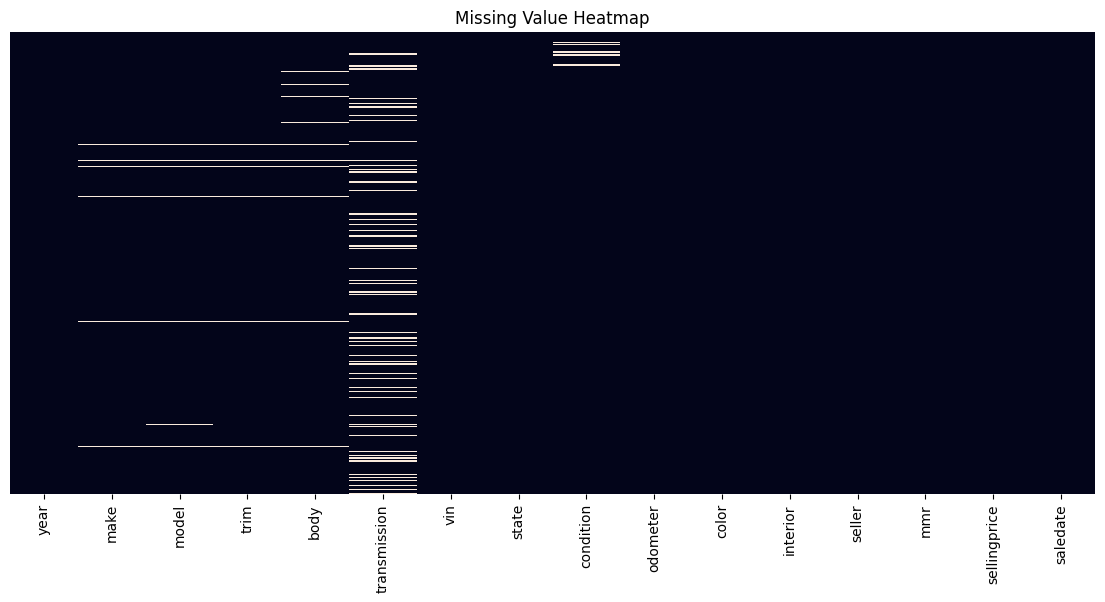

In [28]:
plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap")
plt.show()



### Analyzing, resolving and finding missing columns

In [29]:
missing_df
df.dtypes

,0
year,int64
make,object
model,object
trim,object
body,object
transmission,object
vin,object
state,object
condition,float64
odometer,float64


In [30]:
# Fill missing values based on datatype

for col in df.columns:

    # Numeric columns
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(0)

    # String/Object columns
    elif df[col].dtype == 'object':
        df[col] = df[col].fillna('Null')

In [31]:
# Check missing values again
print(df.isnull().sum())

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64


# 2. Data frames Queries:


### Calculate the average, minimum, and maximum car price?


In [32]:
# Summary statistics for selling price

price_summary = {
    "Average Price": df['sellingprice'].mean(),
    "Minimum Price": df['sellingprice'].min(),
    "Maximum Price": df['sellingprice'].max()
}

for key, value in price_summary.items():
    print(f"{key}: {value:,.2f}")

Average Price: 13,611.07
Minimum Price: 0.00
Maximum Price: 230,000.00


#### List all unique colors of cars?


In [36]:
# Total unique colors count

unique_colors = df['color'].dropna().unique()

print("Unique Colors:")
print(unique_colors)

print("\nTotal Unique Colors Count:", len(unique_colors))

Unique Colors:
['white' 'gray' 'black' 'red' 'silver' 'blue' 'brown' 'beige' 'purple'
 'burgundy' 'â€”' 'gold' 'yellow' 'green' 'charcoal' 'Null' 'orange'
 'off-white' 'turquoise' 'pink' 'lime' 4802 9410 1167 2172 14872 12655
 15719 6388 16633 11034 2711 6864 339 18384 9887 9837 20379 20627 721 6158
 2817 5705 18561 2846 9562 5001]

Total Unique Colors Count: 47


#### Find the number of unique car brands and car models?


In [41]:
# Number of unique car brands
unique_brands = df['make'].nunique()

# Number of unique car models
unique_models = df['model'].nunique()

print("Total Unique Car Brands:", unique_brands)
print("Total Unique Car Models:", unique_models)

Total Unique Car Brands: 97
Total Unique Car Models: 974


In [44]:
print("Unique Car Brands:")
print(sorted(df['make'].dropna().unique()))
unique_models = sorted(df['model'].dropna().astype(str).unique())

print("Unique Car Models:")
print(unique_models)



Unique Car Brands:
['Acura', 'Aston Martin', 'Audi', 'BMW', 'Bentley', 'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Daewoo', 'Dodge', 'FIAT', 'Ferrari', 'Fisker', 'Ford', 'GMC', 'Geo', 'HUMMER', 'Honda', 'Hyundai', 'Infiniti', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Lamborghini', 'Land Rover', 'Lexus', 'Lincoln', 'Lotus', 'MINI', 'Maserati', 'Mazda', 'Mercedes-Benz', 'Mercury', 'Mitsubishi', 'Nissan', 'Null', 'Oldsmobile', 'Plymouth', 'Pontiac', 'Porsche', 'Ram', 'Rolls-Royce', 'Saab', 'Saturn', 'Scion', 'Subaru', 'Suzuki', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo', 'acura', 'airstream', 'audi', 'bmw', 'buick', 'cadillac', 'chev truck', 'chevrolet', 'chrysler', 'dodge', 'dodge tk', 'dot', 'ford', 'ford tk', 'ford truck', 'gmc', 'gmc truck', 'honda', 'hyundai', 'hyundai tk', 'jeep', 'kia', 'land rover', 'landrover', 'lexus', 'lincoln', 'maserati', 'mazda', 'mazda tk', 'mercedes', 'mercedes-b', 'mercury', 'mitsubishi', 'nissan', 'oldsmobile', 'plymouth', 'pontiac', 'porsche', 'smart', 'subar

#### Find all car information having selling prices greater than $165000?


In [53]:
# Summary statistics for selling price
# Find cars with selling price greater than 165000

high_price_cars = df[df['sellingprice'] > 165000]

# Display all matching records
high_price_cars

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


In [54]:
print("Total Cars with Selling Price > $165,000:",
      len(high_price_cars))

Total Cars with Selling Price > $165,000: 7


In [58]:
high_price_cars = df[df['sellingprice'] > 165000]

print("Total Cars Found:", len(high_price_cars))

display(
    high_price_cars[
        ['year', 'make', 'model', 'sellingprice']
    ]
)

Total Cars Found: 7


,year,make,model,sellingprice
125095,2012,Rolls-Royce,Ghost,169500.0
344905,2014,Ford,Escape,230000.0
446949,2015,Mercedes-Benz,S-Class,173000.0
538347,2012,Rolls-Royce,Ghost,167000.0
545523,2013,Rolls-Royce,Ghost,171500.0
548169,2011,Ferrari,458 Italia,183000.0
557570,2012,Rolls-Royce,Ghost,169000.0


#### Find the top 5 most frequently sold car mode

In [60]:
# Top 5 most frequently sold car models

top_5_models = df['model'].value_counts().head(5)

print("Top 5 Most Frequently Sold Car Models:")
print(top_5_models)

Top 5 Most Frequently Sold Car Models:
model
Altima    19349
F-150     14479
Fusion    12946
Camry     12545
Escape    11861
Name: count, dtype: int64


 #### What is the average selling price of cars by brand (make)?

In [62]:
# Average selling price by brand

avg_price_by_brand = (
    df.groupby('make')['sellingprice']
      .mean()
      .sort_values(ascending=False)
)

display(avg_price_by_brand.reset_index())

,make,sellingprice
0,Rolls-Royce,153488.235294
1,Ferrari,127210.526316
2,Lamborghini,112625.000000
3,Bentley,74367.672414
4,airstream,71000.000000
...,...,...
92,dodge tk,550.000000
93,Geo,528.947368
94,dot,500.000000
95,ford truck,483.333333


#### What is the minimum selling price of cars for each interior?

In [64]:
# Minimum selling price for each interior

min_price_by_interior = (
    df.groupby('interior')['sellingprice']
      .min()
)

print(min_price_by_interior)

interior
Null          225.0
beige         100.0
black           0.0
blue          150.0
brown         200.0
burgundy      175.0
gold          250.0
gray            0.0
green         100.0
off-white     900.0
orange       1200.0
purple        200.0
red           200.0
silver        150.0
tan           100.0
white         350.0
yellow       3100.0
â€”             0.0
Name: sellingprice, dtype: float64


#### Find highest odometer reading per year from highest to lowest order?


In [66]:
# Highest odometer reading per year

highest_odometer = (
    df.groupby('year')['odometer']
      .max()
      .reset_index()
      .rename(columns={'odometer': 'Highest Odometer'})
      .sort_values(by='Highest Odometer', ascending=False)
)

display(highest_odometer)

,year,Highest Odometer
15,1997,999999.0
14,1996,999999.0
32,2014,999999.0
31,2013,999999.0
16,1998,999999.0
17,1999,999999.0
11,1993,999999.0
28,2010,999999.0
27,2009,999999.0
30,2012,999999.0


#### Create a new column for car age (assuming the current year is 2025)

In [68]:
# Create car age column

df['car_age'] = 2025 - df['year']

# Display first few rows
df[['year', 'car_age']].head()

,year,car_age
0,2015,10
1,2015,10
2,2014,11
3,2015,10
4,2014,11


#### Find the number of cars having a condition greater than or equal to 48 and odometer greater than 90000?

In [72]:
# Filter cars based on condition and odometer

filtered_cars = df[
    (df['condition'] >= 48) &
    (df['odometer'] > 90000)
]

# Count matching cars
print("Number of Cars:", len(filtered_cars))

Number of Cars: 746


In [74]:
filtered_cars = df[
    (df['condition'] >= 48) &
    (df['odometer'] > 90000)
]

display(
    filtered_cars[
        ['year', 'make', 'model', 'condition', 'odometer', 'sellingprice']
    ]
)

,year,make,model,condition,odometer,sellingprice
3230,2008,HUMMER,H3,48.0,91132.0,15300.0
3767,2006,Chevrolet,Silverado 1500,49.0,97742.0,13250.0
4365,2005,Toyota,4Runner,48.0,155887.0,9500.0
6743,2010,Mercedes-Benz,M-Class,49.0,92966.0,19250.0
9814,2011,Honda,Accord,48.0,93763.0,9000.0
...,...,...,...,...,...,...
554633,2007,Acura,MDX,48.0,113131.0,15500.0
554693,2007,HUMMER,H3,48.0,113993.0,9500.0
556010,2008,Ford,F-350 Super Duty,48.0,92268.0,23400.0
556929,2010,GMC,Acadia,49.0,113337.0,13100.0


#### Which state consistently has higher car prices for newer
cars(year>2013)?


In [77]:
# Filter cars manufactured after 2013

cars_after_2013 = df[df['year'] > 2013]

# Calculate average selling price by state

state_price = (
    cars_after_2013
    .groupby('state')['sellingprice']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

display(state_price)

,sellingprice
state,
oh,28020.22
ab,25204.26
nj,24237.06
on,22962.56
qc,22722.94
...,...
3vwd17aj5fm225953,13200.00
3vwd17aj8fm239622,13200.00
3vwd17aj3fm276741,13200.00


####  For cars with excellent condition (top 20%), which makes have the lowest average price (value for money)?italicized text

In [79]:
# Step 1: Find the condition threshold for top 20%

condition_threshold = df['condition'].quantile(0.80)

print("Top 20% Condition Threshold:", condition_threshold)

# Step 2: Filter excellent-condition cars

excellent_cars = df[
    df['condition'] >= condition_threshold
]

# Step 3: Average selling price by make

value_for_money = (
    excellent_cars
    .groupby('make')['sellingprice']
    .mean()
    .round(2)
    .sort_values()
)

display(value_for_money)

Top 20% Condition Threshold: 43.0


,sellingprice
make,
Isuzu,1125.00
Oldsmobile,1910.00
honda,4233.33
Saturn,5700.41
subaru,6200.00
...,...
Tesla,66580.00
Bentley,96040.00
Lamborghini,113000.00


In [80]:
top_10_value_brands = (
    excellent_cars
    .groupby('make')['sellingprice']
    .mean()
    .round(2)
    .sort_values()
    .head(10)
)

display(top_10_value_brands)

,sellingprice
make,
Isuzu,1125.00
Oldsmobile,1910.00
honda,4233.33
Saturn,5700.41
subaru,6200.00
chrysler,6225.00
smart,6835.76
mazda,7275.00
Pontiac,7686.82


# Data Visualization and insights

#### Show the correlation of all the features(columns) having numerical values(e.g. selling price, odometer)

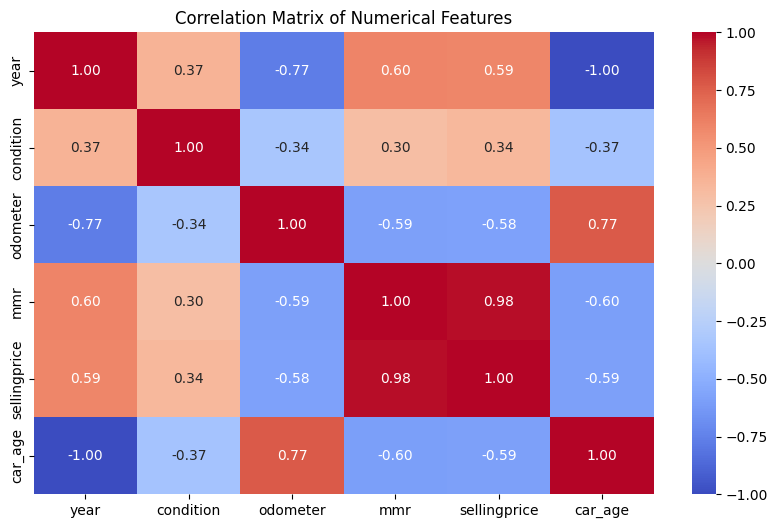

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create correlation heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()

#### Plot a graph to show the average selling price by year and explain the pattern you notice from the graph. Which plot will you use bar or scatter?


In [86]:
avg_price_by_year = (
    df.groupby('year')['sellingprice']
      .mean()
      .round(2)
      .reset_index()
)

display(avg_price_by_year)

,year,sellingprice
0,1982,12750.00
1,1983,5250.00
2,1984,2160.00
3,1985,3520.00
4,1986,2538.64
5,1987,1512.50
6,1988,3168.18
7,1989,1620.00
8,1990,1435.71
9,1991,943.66


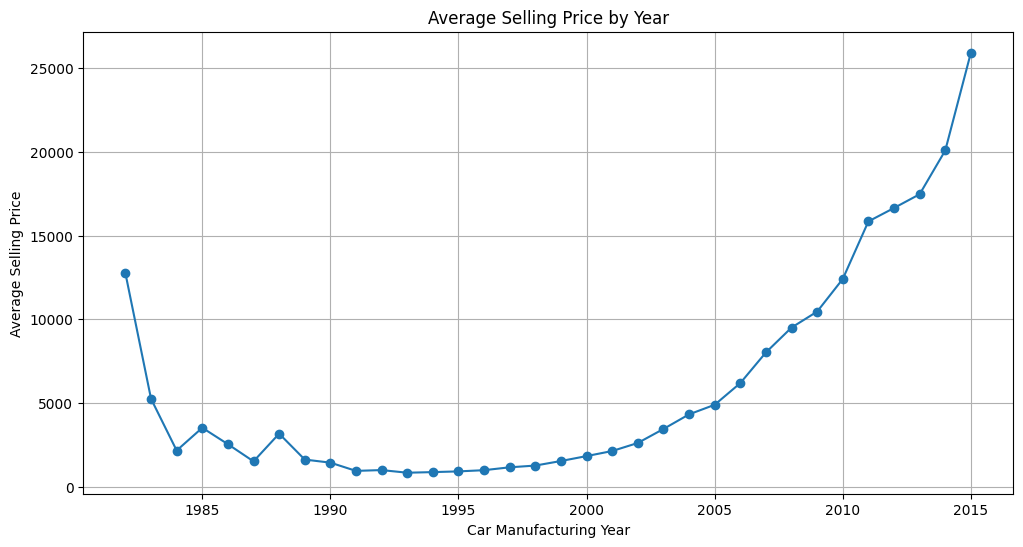

In [87]:
import matplotlib.pyplot as plt

avg_price_by_year = (
    df.groupby('year')['sellingprice']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    avg_price_by_year['year'],
    avg_price_by_year['sellingprice'],
    marker='o'
)

plt.title('Average Selling Price by Year')
plt.xlabel('Car Manufacturing Year')
plt.ylabel('Average Selling Price')

plt.grid(True)

plt.show()

#### Plot a graph to show average selling price by odometer and explain the trend you notice from the graph

/tmp/ipykernel_676/438440191.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('odometer_range')['sellingprice']


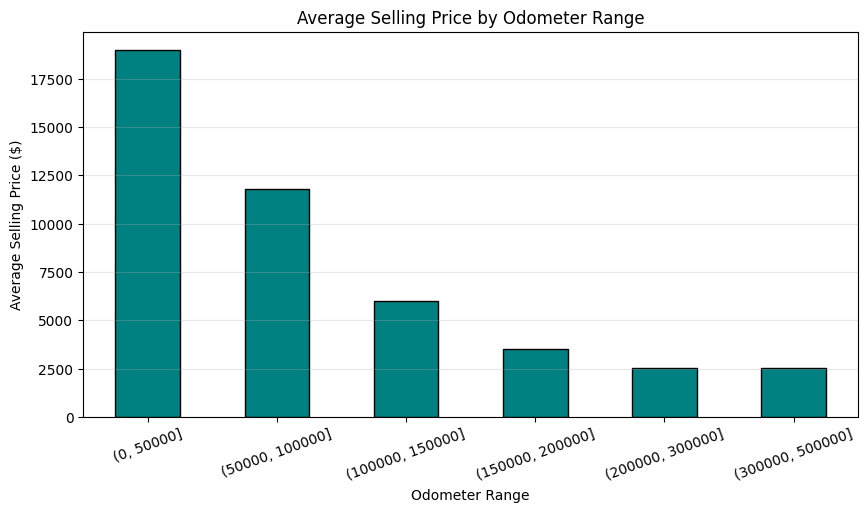

In [89]:
# Create odometer ranges

df['odometer_range'] = pd.cut(
    df['odometer'],
    bins=[0,50000,100000,150000,200000,300000,500000]
)

# Calculate average selling price

avg_price = (
    df.groupby('odometer_range')['sellingprice']
      .mean()
      .round(2)
)

# Plot

plt.figure(figsize=(10,5))

avg_price.plot(
    kind='bar',
    color='teal',
    edgecolor='black'
)

plt.title("Average Selling Price by Odometer Range")
plt.xlabel("Odometer Range")
plt.ylabel("Average Selling Price ($)")

plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)

plt.show()

#### Plot a graph to show the number of cars sold in each state. Find the top three highest car selling states by having a look at the graph?

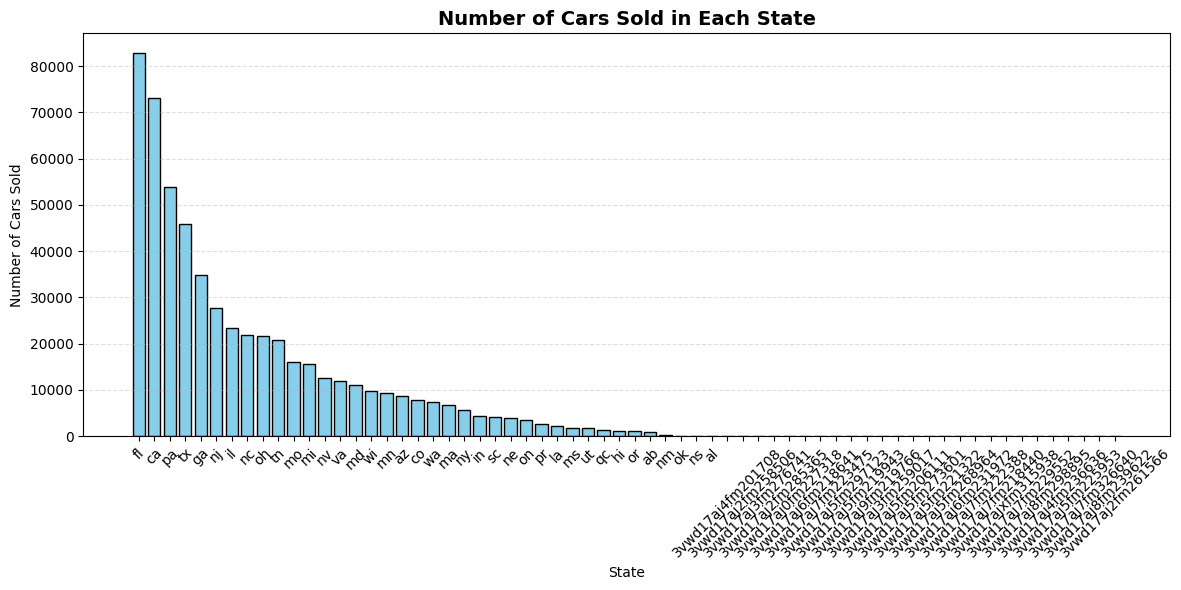

In [99]:
# Number of cars sold in each state

state_sales = df['state'].value_counts()

plt.figure(figsize=(12,6))

bars = plt.bar(
    state_sales.index,
    state_sales.values,
    color='skyblue',
    edgecolor='black'
)

plt.title(
    "Number of Cars Sold in Each State",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("State")
plt.ylabel("Number of Cars Sold")

plt.xticks(rotation=45)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

In [102]:
# Top 3 states with highest car sales

top_3_states = df['state'].value_counts().head(3)

print("Top 3 States by Car Sales:")
print(top_3_states)

Top 3 States by Car Sales:
state
fl    82945
ca    73148
pa    53907
Name: count, dtype: int64


#### Plot a bar graph of average selling price by condition score ranges of size 5. Give a summary of the insigh

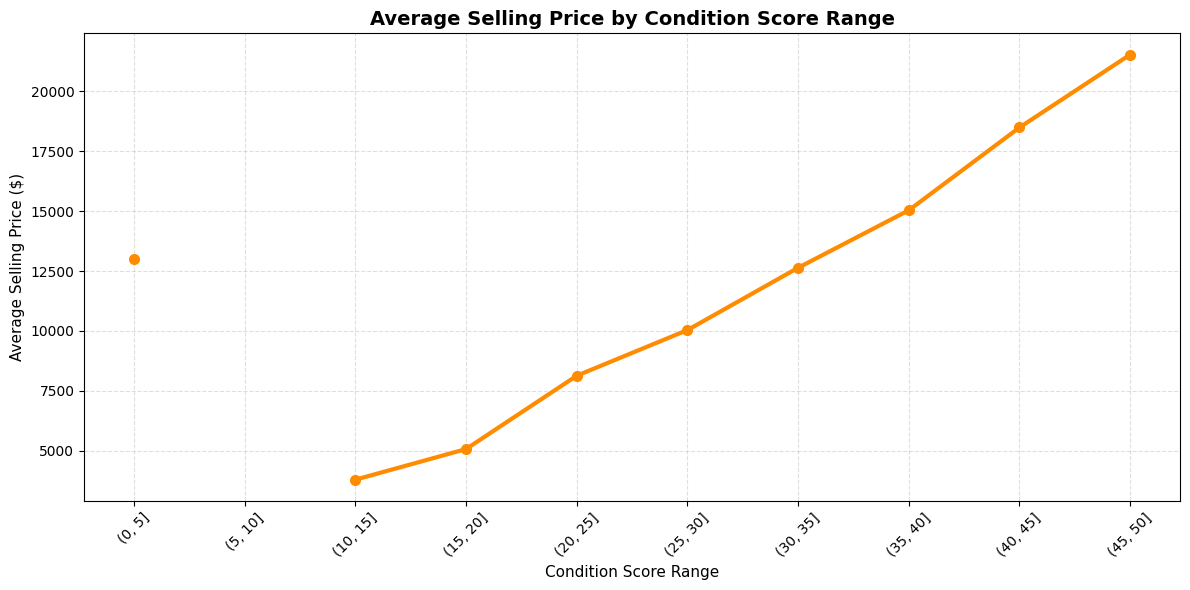

In [108]:



df['condition_range'] = pd.cut(
    df['condition'],
    bins=range(0, 105, 5)
)


avg_price_condition = (
    df.groupby(
        'condition_range',
        observed=False
    )['sellingprice']
      .mean()
      .round(2)
)


plt.figure(figsize=(12,6))

plt.plot(
    avg_price_condition.index.astype(str),
    avg_price_condition.values,
    marker='o',
    linewidth=3,
    markersize=7,
    color='darkorange'
)

plt.title(
    "Average Selling Price by Condition Score Range",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    "Condition Score Range",
    fontsize=11
)

plt.ylabel(
    "Average Selling Price ($)",
    fontsize=11
)

plt.xticks(rotation=45)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

#### Plot a bar graph of no. of cars sold by condition ranges of size 10. Give some insights from the graph.

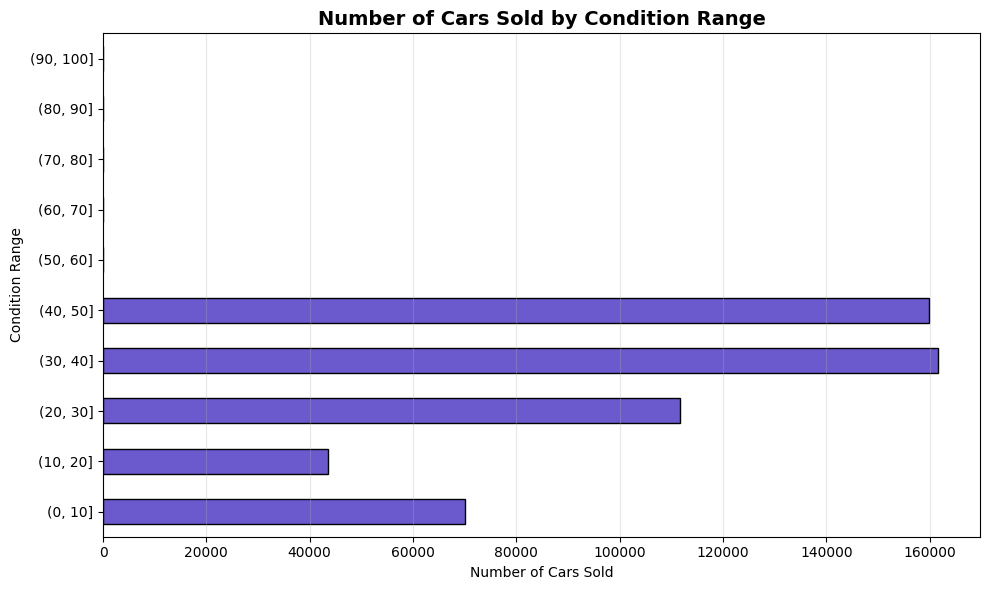

In [112]:


# Create condition ranges of size 10

df['condition_range'] = pd.cut(
    df['condition'],
    bins=range(0, 110, 10)
)


cars_count = (
    df.groupby(
        'condition_range',
        observed=False
    )
    .size()
)


plt.figure(figsize=(10,6))

cars_count.plot(
    kind='barh',
    color='slateblue',
    edgecolor='black'
)

plt.title(
    "Number of Cars Sold by Condition Range",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Number of Cars Sold")
plt.ylabel("Condition Range")

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

#### Plot a box plot to show the distribution of car selling prices grouped by color. Extract insights and if required, remove outliers and plot the graph again.


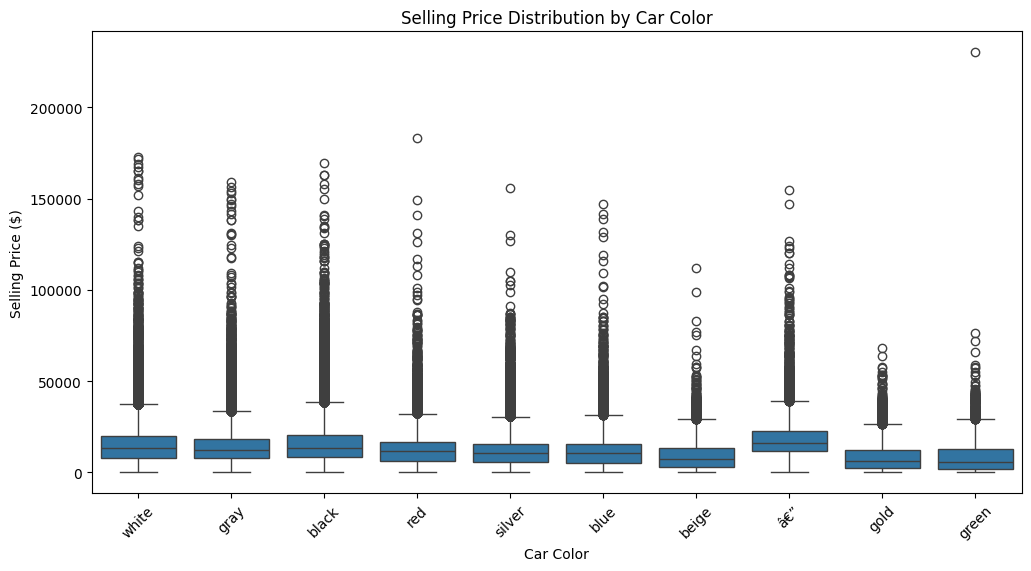

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 colors

top_colors = df['color'].value_counts().head(10).index

df_color = df[df['color'].isin(top_colors)]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_color,
    x='color',
    y='sellingprice'
)

plt.title("Selling Price Distribution by Car Color")
plt.xlabel("Car Color")
plt.ylabel("Selling Price ($)")

plt.xticks(rotation=45)

plt.show()



##Conclusion

📊 The main factors influencing selling prices were found to be the condition, age, mileage (odometer), and brand of the vehicle.  
📈 Generally, newer cars and those in better condition fetched higher selling prices.  
📉 Vehicles with higher mileage were associated with lower resale values.  
🏆 Certain brands consistently displayed higher average selling prices, reflecting a stronger demand in the market.  
🌎 Car sales were predominantly located in a few states, which accounted for a significant portion of total transactions.  
🔍 Analysis of correlations and visualizations revealed key trends and relationships within the data.  
✅ In summary, the project illustrated how tools like Pandas, Matplotlib, and Seaborn can convert raw data into valuable business insights and facilitate data-driven decision-making. 🚀📊